==> Build TRAIN (equalized via augment, YAMNet embeddings)...
[TRAIN] audioanjing: 23 file → 1 crop/file (target≈20)



[TRAIN] audiobabi: 24 file → 1 crop/file (target≈20)
[TRAIN] audiobajingan: 24 file → 1 crop/file (target≈20)
[TRAIN] audiobangsat: 132 file → 1 crop/file (target≈20)
[TRAIN] audiogoblok: 137 file → 1 crop/file (target≈20)
[TRAIN] audiojancuk: 122 file → 1 crop/file (target≈20)
[TRAIN] audiotai: 98 file → 1 crop/file (target≈20)
[TRAIN] audiotolol: 114 file → 1 crop/file (target≈20)
==> Build VAL (1 segmen / file, deterministic)...
[VAL] audioanjing: 23 file → 1 crop/file (target≈23)
[VAL] audiobabi: 24 file → 1 crop/file (target≈24)
[VAL] audiobajingan: 24 file → 1 crop/file (target≈24)
[VAL] audiobangsat: 132 file → 1 crop/file (target≈132)
[VAL] audiogoblok: 137 file → 1 crop/file (target≈137)
[VAL] audiojancuk: 122 file → 1 crop/file (target≈122)
[VAL] audiotai: 98 file → 1 crop/file (target≈98)
[VAL] audiotolol: 114 file → 1 crop/file (target≈114)
Shapes (embeddings): (674, 1024) (674, 1024) | num_classes: 8 ['audioanjing', 'audiobabi', 'audiobajingan', 'audiobangsat', 'audiogoblo

Model: "yamnet_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 598,152 (2.28 MB)

 Trainable params: 594,824 (2.27 MB)

 Non-trainable params: 3,328 (13.00 KB)

Epoch 1/60
20/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1106 - loss: 3.1876
Epoch 1: val_loss improved from None to 2.10592, saving model to best_yamnet_head.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.1588 - loss: 3.0143 - val_accuracy: 0.2240 - val_loss: 2.1059 - learning_rate: 0.0010
Epoch 2/60
19/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3792 - loss: 1.8583
Epoch 2: val_loss improved from 2.10592 to 2.07297, saving model to best_yamnet_head.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3487 - loss: 1.9531 - val_accuracy: 0.2463 - val_loss: 2.0730 - learning_rate: 0.0010
Epoch 3/60
19/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5269 - loss: 1.4962
Epoch 3: val_loss improved from 2.07297 to 2.05309, saving model to best_yamnet_head.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4985 - loss: 1.5401 - val_accuracy: 0.2359 - val_loss: 2.0531 - learning_rate: 0.0010
Epoch 4/60
18/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accura

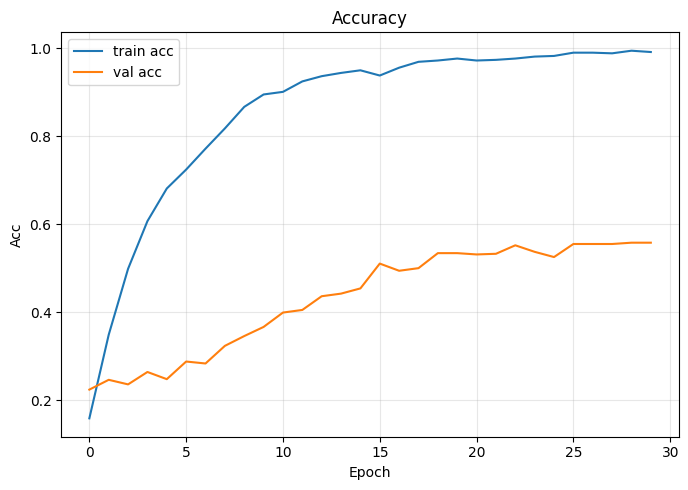

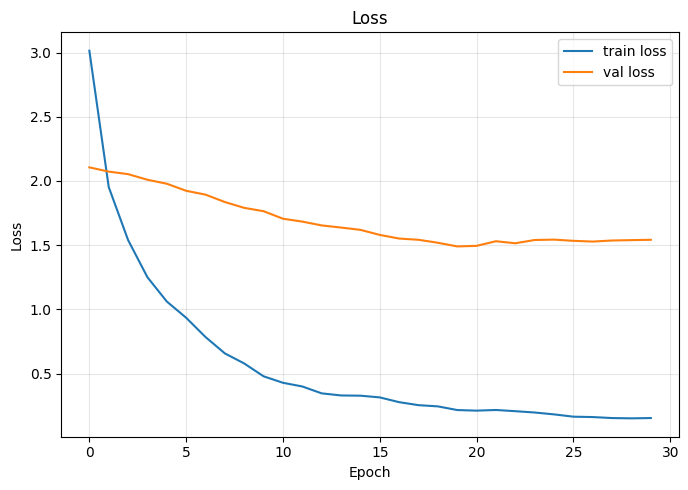

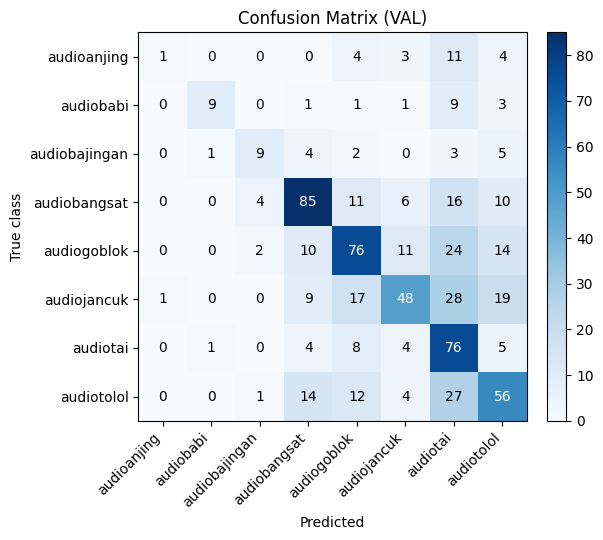

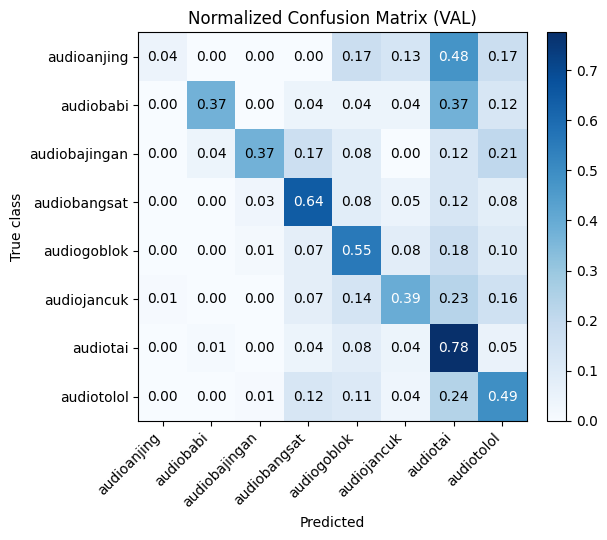

In [2]:
# ===================================================================
# Transfer Learning YAMNet (TF-Hub) → 1024-d Embedding → Classifier
# ===================================================================
# - Semua file dipakai
# - TRAIN dibikin seimbang 20 contoh/kelas via energy-based cropping
# - VAL deterministik (1 segmen RMS tertinggi per file)
# - Head MLP ringan dilatih di atas embedding YAMNet (frozen)
# ===================================================================

import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
from pathlib import Path
import librosa, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import importlib, sys, subprocess
try:
    importlib.import_module("tensorflow_hub")
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow_hub==0.16.1"])
import tensorflow_hub as hub

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
import tensorflow_hub as hub

# ------------------- Config -------------------
DATA_DIR   = r"D:\web\cnn_clasification\archive\Data\genres_original"  # ganti ke foldermu
SR_YAMNET  = 16000        # YAMNet wajib 16 kHz mono
WIN_SEC    = 2.0          # durasi segmen (detik) cocok untuk kata/ujaran pendek
STEP_SEC   = 0.5          # hop untuk scanning RMS
TOPK_TRAIN = 5            # TRAIN: sampling acak dari K segmen RMS tertinggi per file

# Samakan jumlah contoh TRAIN per kelas via augment (tanpa buang file)
BALANCE_TO_PER_CLASS = {
    "audioanjing":   20,
    "audiobabi":     20,
    "audiobajingan": 20,
    "audiobangsat": 20,
    "audiogoblok": 20,
    "audiojancuk": 20,
    "audiotai": 20,
    "audiotolol": 20,
}

SEED       = 42
LR         = 1e-3
EPOCHS     = 60
BATCH_SIZE = 32
L2W        = 1e-4
DROPOUT    = 0.35

np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# ------------------- I/O & DSP -------------------
def list_audio_files(root, exts=(".wav",".mp3",".flac",".ogg",".m4a",".WAV",".MP3",".FLAC")):
    root = Path(root)
    return [p for p in sorted(root.rglob("*")) if p.suffix in exts and p.is_file()]

def load_full_16k(path, sr=SR_YAMNET):
    y, _ = librosa.load(path, sr=sr, mono=True)
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    # pre-emphasis kecil untuk kejelasan konsonan
    y = np.append(y[0], y[1:] - 0.97 * y[:-1])
    return y

def scan_rms(y, sr=SR_YAMNET, win_sec=WIN_SEC, step_sec=STEP_SEC):
    win  = int(win_sec * sr)
    step = int(step_sec * sr)
    if len(y) < win:
        y = np.pad(y, (0, win - len(y)))
    starts = np.arange(0, len(y) - win + 1, step)
    if starts.size == 0: starts = np.array([0])
    rms = np.array([np.sqrt(np.mean(y[s:s+win]**2)) + 1e-8 for s in starts], dtype=np.float32)
    return starts, rms, win

def crop_at(y, start, win):
    end = start + win
    if end > len(y): y = np.pad(y, (0, end - len(y)))
    return y[start:end]

def l2_normalize_audio(seg):
    # optional: norm energi per-segmen agar setara loudness (membantu robust)
    rms = np.sqrt(np.mean(seg**2)) + 1e-8
    return seg / rms

# ------------------- YAMNet (TF-Hub) -------------------
# Akan mengunduh model saat pertama dipanggil.
yamnet = hub.KerasLayer("https://tfhub.dev/google/yamnet/1",
                        trainable=False, name="yamnet")

@tf.function
def yamnet_embed_tf(waveform):
    """
    waveform: tf.float32, shape [N] atau [batch, N], range roughly [-1, 1]
    return: tf.Tensor [num_patches, 1024] atau [batch, num_patches, 1024]
    """
    # YAMNet output: scores [frames, 521], embeddings [frames, 1024], spectrogram [frames, 64]
    outputs = yamnet(waveform)
    if isinstance(outputs, (list, tuple)):
        scores, embeddings, spect = outputs
    else:
        # fallback (seandainya API berubah)
        embeddings = outputs
    return embeddings

def embed_clip_numpy(seg_16k):
    """
    seg_16k: np.ndarray [samples] @ 16kHz
    return mean-pooled embedding: np.ndarray [1024]
    """
    wf = tf.convert_to_tensor(seg_16k, dtype=tf.float32)
    emb = yamnet_embed_tf(wf)   # [frames, 1024]
    emb = tf.reduce_mean(emb, axis=0)  # mean-pool across frames
    return emb.numpy()

# ------------------- Dataset builder (to embeddings) -------------------
def build_yamnet_dataset(data_dir, mode="train", balance_to_per_class=None, topk_train=TOPK_TRAIN):
    """
    mode='train': augment sampai target per-kelas (pakai semua file; sampling dari top-K RMS segmen).
    mode='val'  : 1 segmen RMS tertinggi per file (deterministik).
    Keluaran: (X_embeds, y, class_names, paths)
      - X_embeds: np.ndarray [N, 1024]
      - y:        np.ndarray [N], int labels
    """
    root = Path(data_dir)
    class_names = sorted([d.name for d in root.iterdir() if d.is_dir()])
    X_embeds, y_list, paths = [], [], []

    for ci, cname in enumerate(class_names):
        files = list_audio_files(root / cname)
        # Tentukan target per kelas (TRAIN) → samakan ke target; VAL = jumlah file
        if mode == "train" and balance_to_per_class is not None:
            target = balance_to_per_class.get(cname, len(files))
        else:
            target = len(files)

        rep = max(1, int(np.ceil(target / max(1, len(files)))))
        print(f"[{mode.upper()}] {cname}: {len(files)} file → {rep} crop/file (target≈{target})")

        for f in files:
            try:
                y_full = load_full_16k(str(f))
                starts, rms, win = scan_rms(y_full, sr=SR_YAMNET)

                if mode == "train":
                    pick = np.argsort(rms)[::-1][:min(topk_train, len(rms))]
                    for _ in range(rep):
                        s = np.random.choice(pick)
                        seg = crop_at(y_full, starts[s], win)
                        seg = l2_normalize_audio(seg)
                        emb = embed_clip_numpy(seg)   # [1024]
                        X_embeds.append(emb); y_list.append(ci); paths.append(str(f))
                else:
                    s = int(np.argmax(rms))  # deterministik: segmen terbaik
                    seg = crop_at(y_full, starts[s], win)
                    seg = l2_normalize_audio(seg)
                    emb = embed_clip_numpy(seg)       # [1024]
                    X_embeds.append(emb); y_list.append(ci); paths.append(str(f))
            except Exception as e:
                print("  Gagal:", f, e)

    X_embeds = np.stack(X_embeds, axis=0).astype(np.float32)  # [N, 1024]
    y = np.array(y_list, dtype=np.int64)
    return X_embeds, y, class_names, np.array(paths)

print("==> Build TRAIN (equalized via augment, YAMNet embeddings)...")
Xtr, ytr, class_names, _ = build_yamnet_dataset(
    DATA_DIR, mode="train", balance_to_per_class=BALANCE_TO_PER_CLASS
)
print("==> Build VAL (1 segmen / file, deterministic)...")
Xval, yval, _, _ = build_yamnet_dataset(DATA_DIR, mode="val")

print("Shapes (embeddings):", Xtr.shape, Xval.shape, "| num_classes:", len(class_names), class_names)

# ------------------- Classifier Head -------------------
def build_head(input_dim, num_classes, l2w=L2W, drop=DROPOUT):
    inp = layers.Input(shape=(input_dim,))
    x = layers.BatchNormalization()(inp)
    x = layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(l2w))(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(drop)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2w))(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(drop)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out, name="yamnet_head")

num_classes = len(class_names)
head = build_head(input_dim=1024, num_classes=num_classes)
head.summary()

opt = optimizers.Adam(learning_rate=LR)
head.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint("best_yamnet_head.keras", monitor="val_loss", save_best_only=True, verbose=1),
]

hist = head.fit(
    Xtr, ytr,
    validation_data=(Xval, yval),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cbs,
    verbose=1
)

# ------------------- Evaluasi -------------------
yval_prob = head.predict(Xval, verbose=0)
yval_pred = np.argmax(yval_prob, axis=1)
print("Val acc:", accuracy_score(yval, yval_pred))
print(classification_report(yval, yval_pred, target_names=class_names, digits=4))
cm = confusion_matrix(yval, yval_pred)
print("Confusion:\n", cm)

# ------------------- Plotting -------------------
def plot_history(h):
    plt.figure(figsize=(7,5))
    plt.plot(h.history['accuracy'], label='train acc')
    plt.plot(h.history['val_accuracy'], label='val acc')
    plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc')
    plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(h.history['loss'], label='train loss')
    plt.plot(h.history['val_loss'], label='val loss')
    plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

plot_history(hist)

def plot_cm(cm, class_names, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9); fmt=".2f"
    else:
        fmt="d"
    plt.figure(figsize=(6.5,5.5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title); plt.colorbar(fraction=0.046, pad=0.04)
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right"); plt.yticks(ticks, class_names)
    thresh = cm.max()/2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True class"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

plot_cm(cm, class_names, normalize=False, title="Confusion Matrix (VAL)")
plot_cm(cm, class_names, normalize=True,  title="Normalized Confusion Matrix (VAL)")

# ------------------- TTA (Multi-crop voting) untuk 1 file -------------------
def predict_file_tta(file_path, head_model, starts_sec=(0.0, 0.25, 0.5, 0.75, 1.0),
                     sr=SR_YAMNET, win_sec=WIN_SEC):
    y = load_full_16k(file_path)
    win = int(win_sec * sr)
    probs = []
    for st in starts_sec:
        s = int(st * sr); e = s + win
        if e > len(y):
            seg = np.pad(y[s:], (0, e - len(y)))
        else:
            seg = y[s:e]
        seg = l2_normalize_audio(seg)
        emb = embed_clip_numpy(seg)[None, :]  # [1,1024]
        p = head_model.predict(emb, verbose=0)[0]
        probs.append(p)
    p_mean = np.mean(probs, axis=0)
    return p_mean, int(np.argmax(p_mean))

# Contoh pakai (uncomment & ganti path):
# p, cls = predict_file_tta(r"D:\path\to\audio.wav", head, starts_sec=(0.0,0.25,0.5))
# print("Pred:", class_names[cls], "probs:", p)
